In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

import perceval as pcvl
import perceval.components as symb
import numpy as np
import sympy as sp
import networkx as nx

import sys
sys.path.append('..')
from compiler.LOTree import fuse2, sink
from compiler.Loop import Loop
from compiler.PhotonicQubit import photons_from_qubit, Qbit

In [9]:
G = nx.Graph()
G.add_nodes_from([0,1,2,3,4,5,6,7,8])
G.add_edge(0,1)
G.add_edge(1,2)

G.add_edge(3,4)
G.add_edge(4,5)

G.add_edge(6,7)
G.add_edge(7,8)

sg = pcvl.stategenerator.StateGenerator(pcvl.Encoding.DUAL_RAIL)
instate = sg.graph_state(graph=G)
# pcvl.pdisplay(instate)

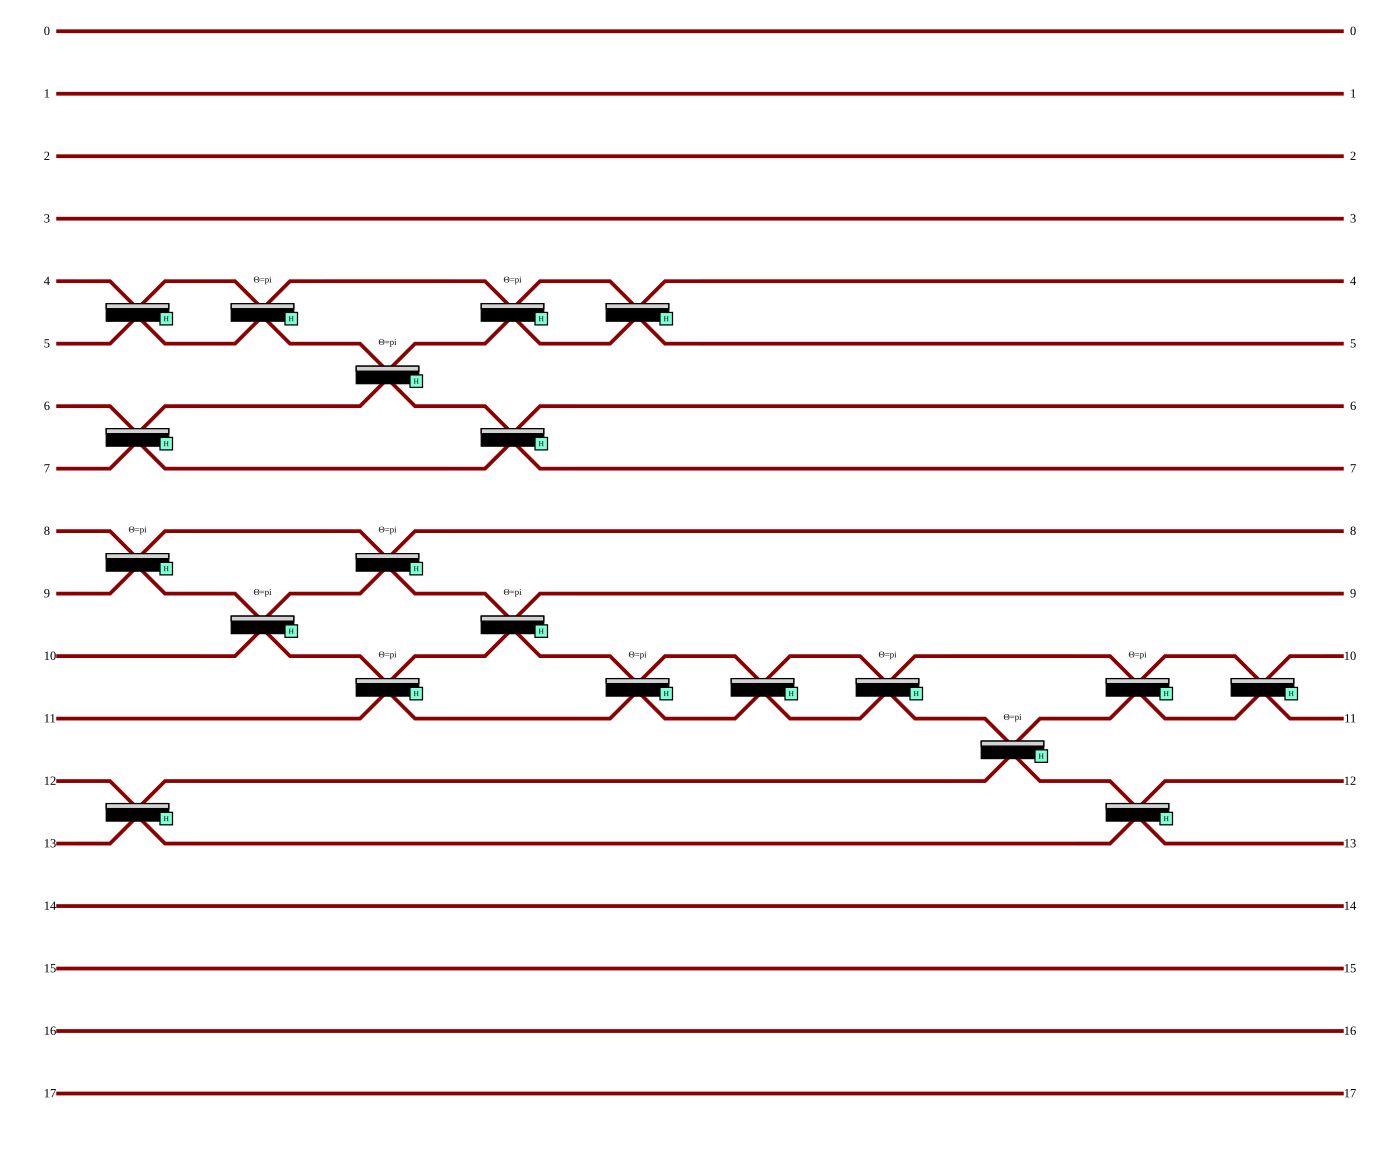

In [10]:
ghzfuser = pcvl.Circuit(18, name = "ghzfuser")
q0 = Qbit(0, logical=False)
q1 = Qbit(2, logical=False)
q2 = Qbit(4, logical=False)
q3 = Qbit(6, logical=False)
q4 = Qbit(8, logical=False)
q5 = Qbit(10, logical=False)
q6 = Qbit(12, logical=False)
q7 = Qbit(14, logical=False)
q8 = Qbit(16, logical=False)
l = Loop(circuit=ghzfuser, photons=photons_from_qubit([q0,q1,q2,q3,q4,q5,q6,q7,q8]), qbits=[q0,q1,q2,q3,q4,q5,q6,q7,q8])

l.fuse2(q2,q3)
l.sink(q4, q5)
l.fuse2(q4,q6)
l.in_state = instate
pcvl.pdisplay(ghzfuser)

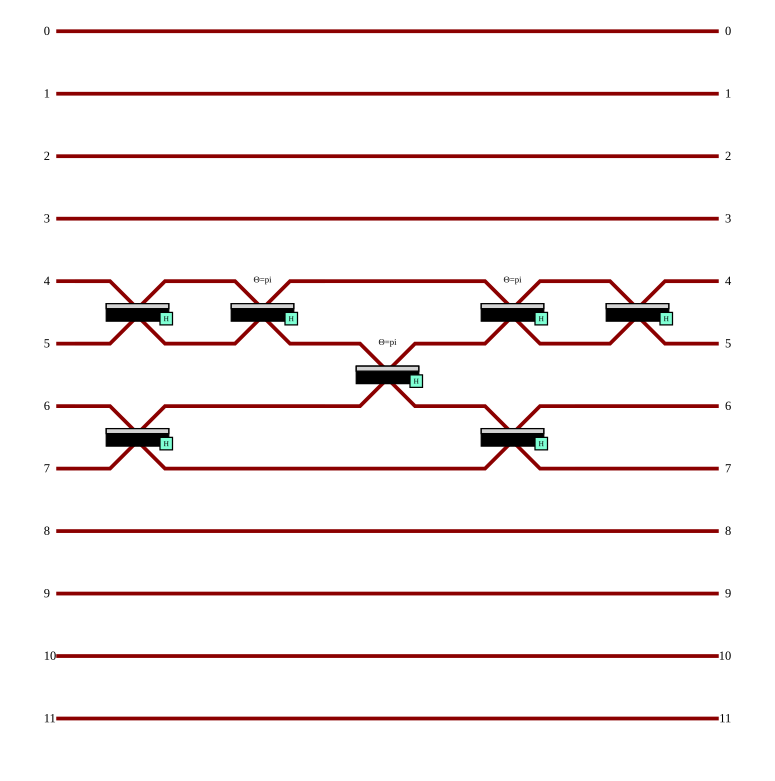

In [30]:
def generate_input_ghzs(num):
    G = nx.Graph()
    G.add_nodes_from(range(num*3))
    for i in range(num):
        G.add_edge(i*3,i*3+1)
        G.add_edge(i*3+1,i*3+2)

    sg = pcvl.stategenerator.StateGenerator(pcvl.Encoding.DUAL_RAIL)
    return sg.graph_state(graph=G)


singleghzfuser = pcvl.Circuit(12, name = "singleghzfuser")
q0 = Qbit(0, logical=False)
q1 = Qbit(2, logical=False)
q2 = Qbit(4, logical=False)
q3 = Qbit(6, logical=False)
q4 = Qbit(8, logical=False)
q5 = Qbit(10, logical=False)
lsingle = Loop(circuit=singleghzfuser, photons=photons_from_qubit([q0,q1,q2,q3,q4,q5]), qbits=[q0,q1,q2,q3,q4,q5])

# lsingle.fuse2(q2,q3)
lsingle.circuit.add((4,5), symb.BS.H())
lsingle.circuit.add((4,5), symb.BS.H(np.pi))
lsingle.circuit.add((6,7), symb.BS.H())
lsingle.circuit.add((5,6), symb.BS.H(np.pi))
lsingle.circuit.add((4,5), symb.BS.H(np.pi))
lsingle.circuit.add((4,5), symb.BS.H())
lsingle.circuit.add((6,7), symb.BS.H())
# l.sink(q4, q5)
# l.fuse2(q4,q6)
lsingle.in_state = generate_input_ghzs(2)
pcvl.pdisplay(singleghzfuser)

In [18]:
def post_select_ghz(circuit, instate, checkmodes):
    #assuming we measure ancillas from ancilla_start to end of circuit
    backend = pcvl.backends.NaiveBackend()
    backend.set_circuit(circuit)
    sum_probs = 0
    sim = pcvl.simulators.Simulator(backend)
    for outstate in get_ghz_post_selected_states(instate, checkmodes):
        probamp = sim.prob_amplitude(instate,pcvl.BasicState(str(outstate)))
        
#         print("test ",outstate,"amplitude",probamp)

        if abs(probamp)**2 > 10e-10:
            print("state ",outstate,"amplitude ",probamp)
                # print("add to ",prob[str(outstate[ancilla_start:])][str(outstate[:ancilla_start])],probamp) #debug

#             keys = []
#             for p in prob.keys():
#                 if prob[p] == {}:
#                     keys.append(p)
#             for k in keys:
#                 del prob[k]

#             pprint(prob)

#         return sum_probs


def get_ghz_post_selected_states(instate, checkmodes):
    res = []

    for state in pcvl.statevector.allstate_iterator(instate):
        check = True
        for mode in checkmodes:
            if state[mode] != 1:
                check=False
        for mode in [x+1 for x in checkmodes]:
            if state[mode] != 0:
                check =False
        if check:
            res.append(state)

    return res

post_select_ghz(lsingle.circuit, generate_input_ghzs(2), [4,6])

state  |1,0,1,0,1,0,1,0,1,0,1,0> amplitude  (0.12500000000000003+0j)
state  |1,0,1,0,1,0,1,0,1,0,0,1> amplitude  (0.125+0j)
state  |1,0,0,1,1,0,1,0,0,1,1,0> amplitude  (0.12499999999999999+0j)
state  |1,0,0,1,1,0,1,0,0,1,0,1> amplitude  (-0.12499999999999999+0j)
state  |0,1,1,0,1,0,1,0,1,0,1,0> amplitude  (0.125+0j)
state  |0,1,1,0,1,0,1,0,1,0,0,1> amplitude  (0.12500000000000003+0j)
state  |0,1,0,1,1,0,1,0,0,1,1,0> amplitude  (-0.12499999999999999+0j)
state  |0,1,0,1,1,0,1,0,0,1,0,1> amplitude  (0.12499999999999999+0j)


In [16]:
post_select_ghz(l.circuit, generate_input_ghzs(3), [4,6,10,12])

state  |1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0> amplitude  (0.044194173824159216+0j)
state  |1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,0,1> amplitude  (0.04419417382415922+0j)
state  |1,0,1,0,1,0,1,0,0,1,1,0,1,0,0,1,1,0> amplitude  (0.0441941738241592+0j)
state  |1,0,1,0,1,0,1,0,0,1,1,0,1,0,0,1,0,1> amplitude  (-0.04419417382415921+0j)
state  |1,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,1,0> amplitude  (0.044194173824159216+0j)
state  |1,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,1> amplitude  (0.04419417382415922+0j)
state  |1,0,0,1,1,0,1,0,0,1,1,0,1,0,0,1,1,0> amplitude  (0.0441941738241592+0j)
state  |1,0,0,1,1,0,1,0,0,1,1,0,1,0,0,1,0,1> amplitude  (-0.0441941738241592+0j)
state  |0,1,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0> amplitude  (0.04419417382415922+0j)
state  |0,1,1,0,1,0,1,0,1,0,1,0,1,0,1,0,0,1> amplitude  (0.04419417382415922+0j)
state  |0,1,1,0,1,0,1,0,0,1,1,0,1,0,0,1,1,0> amplitude  (0.0441941738241592+0j)
state  |0,1,1,0,1,0,1,0,0,1,1,0,1,0,0,1,0,1> amplitude  (-0.04419417382415921+0j)
state  |0,1,0,1,1,0,1,0,1,0

Output corresponds to following circuit: 
```
0-H-|-------
0-H-Z-|-|---
0-H---Z-|---
0-H-----Z-|-
0-H-------Z-
```

In [20]:
checkc = pcvl.Circuit(12, name = "singleghz")
post_select_ghz(checkc, generate_input_ghzs(2), [4,6])

state  |1,0,1,0,1,0,1,0,1,0,1,0> amplitude  (0.125+0j)
state  |1,0,1,0,1,0,1,0,1,0,0,1> amplitude  (0.125+0j)
state  |1,0,1,0,1,0,1,0,0,1,1,0> amplitude  (0.125+0j)
state  |1,0,1,0,1,0,1,0,0,1,0,1> amplitude  (-0.125+0j)
state  |1,0,1,0,1,0,0,1,1,0,1,0> amplitude  (0.125+0j)
state  |1,0,1,0,1,0,0,1,1,0,0,1> amplitude  (0.125+0j)
state  |1,0,1,0,1,0,0,1,0,1,1,0> amplitude  (-0.125+0j)
state  |1,0,1,0,1,0,0,1,0,1,0,1> amplitude  (0.125+0j)
state  |1,0,1,0,0,1,1,0,1,0,1,0> amplitude  (0.125+0j)
state  |1,0,1,0,0,1,1,0,1,0,0,1> amplitude  (0.125+0j)
state  |1,0,1,0,0,1,1,0,0,1,1,0> amplitude  (0.125+0j)
state  |1,0,1,0,0,1,1,0,0,1,0,1> amplitude  (-0.125+0j)
state  |1,0,1,0,0,1,0,1,1,0,1,0> amplitude  (0.125+0j)
state  |1,0,1,0,0,1,0,1,1,0,0,1> amplitude  (0.125+0j)
state  |1,0,1,0,0,1,0,1,0,1,1,0> amplitude  (-0.125+0j)
state  |1,0,1,0,0,1,0,1,0,1,0,1> amplitude  (0.125+0j)
state  |1,0,0,1,1,0,1,0,1,0,1,0> amplitude  (0.125+0j)
state  |1,0,0,1,1,0,1,0,1,0,0,1> amplitude  (0.125+0j)
state 

In [24]:
def generate_input_4ghzs(num):
    G = nx.Graph()
    G.add_nodes_from(range(num*4))
    for i in range(num):
        G.add_edge(i*4,i*4+1)
        G.add_edge(i*4+1,i*4+2)
        G.add_edge(i*4+2,i*4+3)

    sg = pcvl.stategenerator.StateGenerator(pcvl.Encoding.DUAL_RAIL)
    return sg.graph_state(graph=G)

checkc = pcvl.Circuit(8, name = "4ghz")
post_select_ghz(checkc, generate_input_4ghzs(1), [])

state  |1,0,1,0,1,0,1,0> amplitude  (0.25+0j)
state  |1,0,1,0,1,0,0,1> amplitude  (0.25+0j)
state  |1,0,1,0,0,1,1,0> amplitude  (0.25+0j)
state  |1,0,1,0,0,1,0,1> amplitude  (-0.25+0j)
state  |1,0,0,1,1,0,1,0> amplitude  (0.25+0j)
state  |1,0,0,1,1,0,0,1> amplitude  (0.25+0j)
state  |1,0,0,1,0,1,1,0> amplitude  (-0.25+0j)
state  |1,0,0,1,0,1,0,1> amplitude  (0.25+0j)
state  |0,1,1,0,1,0,1,0> amplitude  (0.25+0j)
state  |0,1,1,0,1,0,0,1> amplitude  (0.25+0j)
state  |0,1,1,0,0,1,1,0> amplitude  (0.25+0j)
state  |0,1,1,0,0,1,0,1> amplitude  (-0.25+0j)
state  |0,1,0,1,1,0,1,0> amplitude  (-0.25+0j)
state  |0,1,0,1,1,0,0,1> amplitude  (-0.25+0j)
state  |0,1,0,1,0,1,1,0> amplitude  (0.25+0j)
state  |0,1,0,1,0,1,0,1> amplitude  (-0.25+0j)


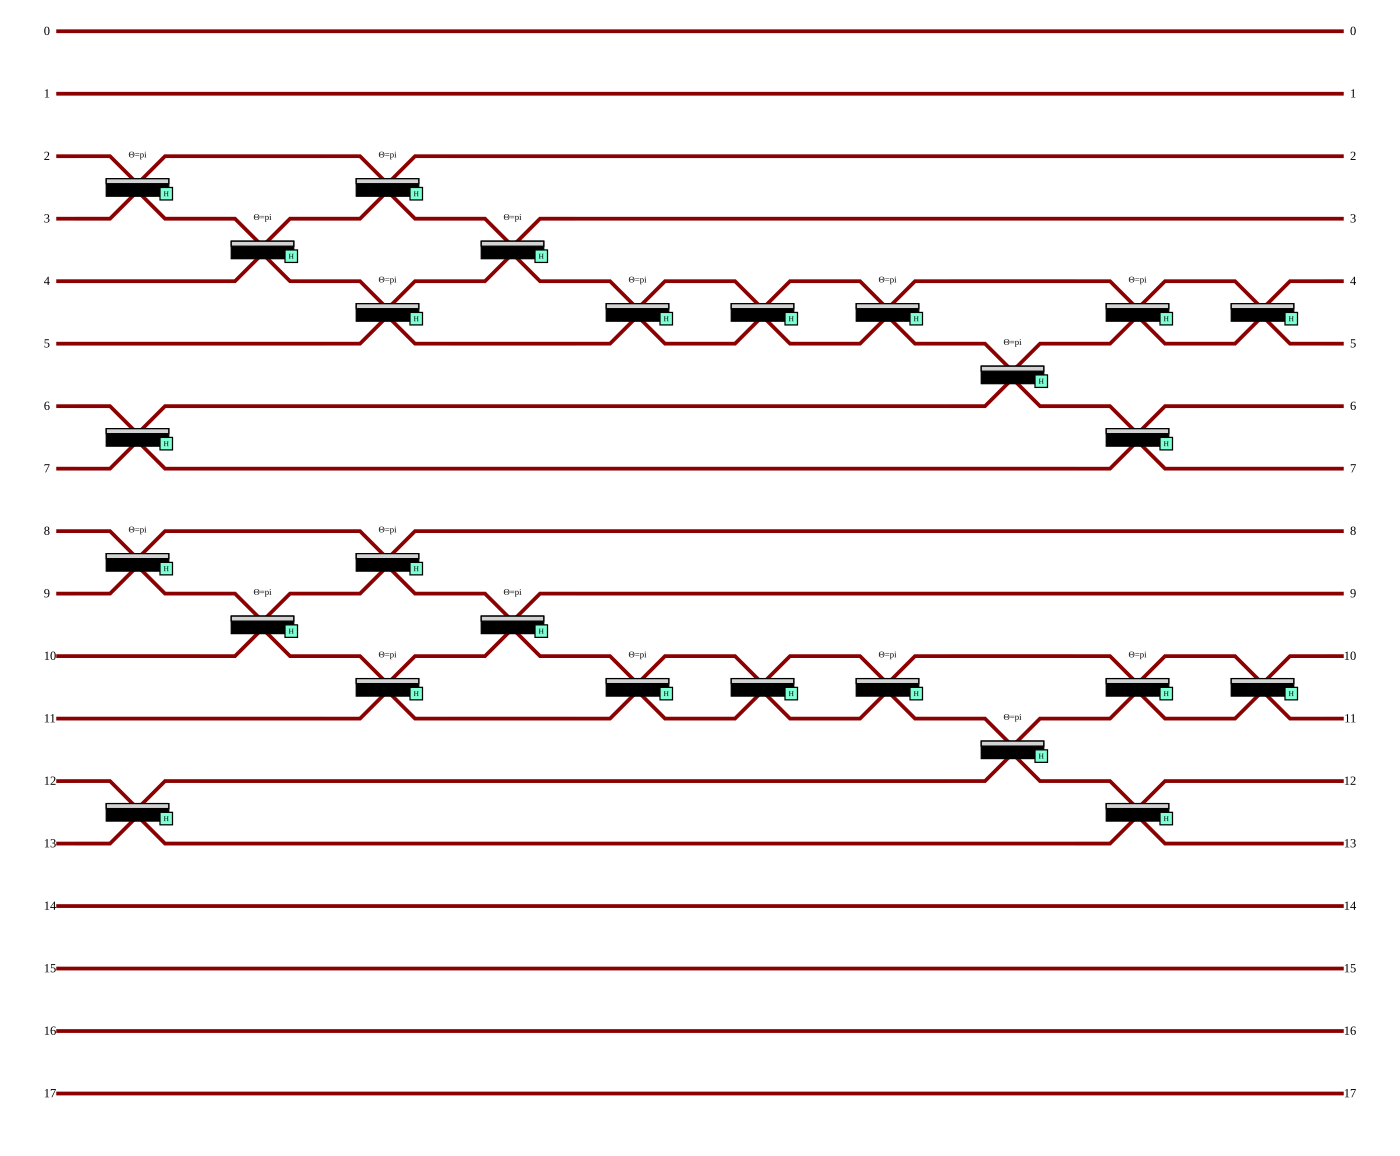

In [25]:
circ = pcvl.Circuit(18, name = "doubleghzfuser")

circ.add((2,3), symb.BS.H(np.pi))
circ.add((8,9), symb.BS.H(np.pi))

circ.add((3,4), symb.BS.H(np.pi))
circ.add((9,10), symb.BS.H(np.pi))

circ.add((2,3), symb.BS.H(np.pi))
circ.add((4,5), symb.BS.H(np.pi))
circ.add((8,9), symb.BS.H(np.pi))
circ.add((10,11), symb.BS.H(np.pi))

circ.add((3,4), symb.BS.H(np.pi))
circ.add((9,10), symb.BS.H(np.pi))

circ.add((4,5), symb.BS.H(np.pi))
circ.add((10,11), symb.BS.H(np.pi))

circ.add((4,5), symb.BS.H())
circ.add((6,7), symb.BS.H())
circ.add((10,11), symb.BS.H())
circ.add((12,13), symb.BS.H())

circ.add((4,5), symb.BS.H(np.pi))
circ.add((10,11), symb.BS.H(np.pi))

circ.add((5,6), symb.BS.H(np.pi))
circ.add((11,12), symb.BS.H(np.pi))

circ.add((4,5), symb.BS.H(np.pi))
circ.add((10,11), symb.BS.H(np.pi))

circ.add((4,5), symb.BS.H())
circ.add((6,7), symb.BS.H())
circ.add((10,11), symb.BS.H())
circ.add((12,13), symb.BS.H())

pcvl.pdisplay(circ)

In [26]:
post_select_ghz(circ, generate_input_ghzs(3), [4,6,10,12])

state  |1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0> amplitude  (0.02209708691207961+0j)
state  |1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,0,1> amplitude  (0.022097086912079615+0j)
state  |1,0,1,0,1,0,1,0,1,0,1,0,1,0,0,1,1,0> amplitude  (0.022097086912079608+0j)
state  |1,0,1,0,1,0,1,0,1,0,1,0,1,0,0,1,0,1> amplitude  (-0.022097086912079608+0j)
state  |1,0,1,0,1,0,1,0,0,1,1,0,1,0,1,0,1,0> amplitude  (0.022097086912079608+0j)
state  |1,0,1,0,1,0,1,0,0,1,1,0,1,0,1,0,0,1> amplitude  (0.022097086912079608+0j)
state  |1,0,1,0,1,0,1,0,0,1,1,0,1,0,0,1,1,0> amplitude  (0.022097086912079615+0j)
state  |1,0,1,0,1,0,1,0,0,1,1,0,1,0,0,1,0,1> amplitude  (-0.022097086912079615+0j)
state  |1,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,1,0> amplitude  (0.022097086912079605+0j)
state  |1,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,1> amplitude  (0.02209708691207961+0j)
state  |1,0,0,1,1,0,1,0,1,0,1,0,1,0,0,1,1,0> amplitude  (-0.0220970869120796+0j)
state  |1,0,0,1,1,0,1,0,1,0,1,0,1,0,0,1,0,1> amplitude  (0.0220970869120796+0j)
state  |1,0,0,1,1,0

In [44]:
def print_qubit_states(state):
    logical_states = dict()
    for component, amplitude in state:
        logical = ""
#         logical = "|"
        for i in range(0,len(component),2):
            if component[i] == 1 and component[i+1] == 0:
                logical += "0"
            elif component[i] == 0 and component[i+1] == 1:
                logical += "1"
            else:
                print("undefined logical representation for",component[i],component[i+1])
        logical_states[logical] = amplitude
    for k in sorted(logical_states.keys()):
        print("|"+k+">:",logical_states[k])

|00000>: (0.17677669529663687+0j)
|00001>: (0.17677669529663687+0j)
|00010>: (0.17677669529663687+0j)
|00011>: (0.17677669529663687+0j)
|00100>: (0.17677669529663687+0j)
|00101>: (0.17677669529663687+0j)
|00110>: (0.17677669529663687+0j)
|00111>: (0.17677669529663687+0j)
|01000>: (0.17677669529663687+0j)
|01001>: (-0.17677669529663687-0j)
|01010>: (-0.17677669529663687-0j)
|01011>: (0.17677669529663687+0j)
|01100>: (-0.17677669529663687-0j)
|01101>: (0.17677669529663687+0j)
|01110>: (0.17677669529663687+0j)
|01111>: (-0.17677669529663687-0j)
|10000>: (0.17677669529663687+0j)
|10001>: (0.17677669529663687+0j)
|10010>: (0.17677669529663687+0j)
|10011>: (0.17677669529663687+0j)
|10100>: (0.17677669529663687+0j)
|10101>: (0.17677669529663687+0j)
|10110>: (0.17677669529663687+0j)
|10111>: (0.17677669529663687+0j)
|11000>: (-0.17677669529663687-0j)
|11001>: (0.17677669529663687+0j)
|11010>: (0.17677669529663687+0j)
|11011>: (-0.17677669529663687-0j)
|11100>: (0.17677669529663687+0j)
|11101>:

In [48]:
# This now finally corresponds to quide (when measuring 01,01 on the fusions)
G = nx.Graph()
G.add_nodes_from(range(5))
G.add_edge(0,3)
G.add_edge(3,2)
G.add_edge(1,3)
G.add_edge(3,4)
sg = pcvl.stategenerator.StateGenerator(pcvl.Encoding.DUAL_RAIL)
print_qubit_states(sg.graph_state(graph=G))

|00000>: (0.17677669529663687+0j)
|00001>: (0.17677669529663687+0j)
|00010>: (0.17677669529663687+0j)
|00011>: (-0.17677669529663687-0j)
|00100>: (0.17677669529663687+0j)
|00101>: (0.17677669529663687+0j)
|00110>: (-0.17677669529663687-0j)
|00111>: (0.17677669529663687+0j)
|01000>: (0.17677669529663687+0j)
|01001>: (0.17677669529663687+0j)
|01010>: (-0.17677669529663687-0j)
|01011>: (0.17677669529663687+0j)
|01100>: (0.17677669529663687+0j)
|01101>: (0.17677669529663687+0j)
|01110>: (0.17677669529663687+0j)
|01111>: (-0.17677669529663687-0j)
|10000>: (0.17677669529663687+0j)
|10001>: (0.17677669529663687+0j)
|10010>: (-0.17677669529663687-0j)
|10011>: (0.17677669529663687+0j)
|10100>: (0.17677669529663687+0j)
|10101>: (0.17677669529663687+0j)
|10110>: (0.17677669529663687+0j)
|10111>: (-0.17677669529663687-0j)
|11000>: (0.17677669529663687+0j)
|11001>: (0.17677669529663687+0j)
|11010>: (0.17677669529663687+0j)
|11011>: (-0.17677669529663687-0j)
|11100>: (0.17677669529663687+0j)
|11101>